# JointPMF Data 

In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


In [26]:
import pickle

subset = 'jpmf_data'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    
    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg_pid/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)
    
    with open(f'{base_dir}/ea_ies_pid/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'{base_dir}/ea_fes_pid/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)
    
    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_ea_hc = pickle.load(f)
    
    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)

    # with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
    #     results_ea_ies = pickle.load(f)
    
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    

    results_by_label = {
        "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        "EA-FG": results_ea_fg,
        "EA-UES": results_ea_ues,
        "EA-IES": results_ea_ies,
        "EA-FES": results_ea_fes,
        "EA-HC": results_ea_hc,
        "PC (GSQ)": results_pc_gsq,
        }


In [27]:
    
# x_col="p_noise"
# y_col="samples"
# filter = ("samples", 10_000)
# filter = ("p_syn", 0.5)
# filter = ("dag_family", "ba")
# filter_col, filter_val = filter

In [28]:
# results_by_label["PC"][0].eval_metrics.columns

In [29]:
import pandas as pd

load_results(subset)

def _eval_to_df(eval_metrics):
    if eval_metrics is None:
        return None
    if isinstance(eval_metrics, pd.DataFrame):
        return eval_metrics.copy()
    if isinstance(eval_metrics, pd.Series):
        return eval_metrics.to_frame().T
    if isinstance(eval_metrics, dict):
        return pd.DataFrame([eval_metrics])
    return None

def build_long_metrics(results_by_label):
    rows = []
    for alg, results_list in results_by_label.items():
        for i, res in enumerate(results_list):
            em = getattr(res, "eval_metrics", None)
            df_em = _eval_to_df(em)
            if df_em is None or len(df_em) == 0:
                continue
            df_em = df_em.copy()
            df_em["Algorithm"] = alg
            df_em["run_id"] = i
            rows.append(df_em)
    return pd.concat(rows, ignore_index=True)

long_df = build_long_metrics(results_by_label)
# long_df = long_df[long_df["Total (SC)"] > 0]


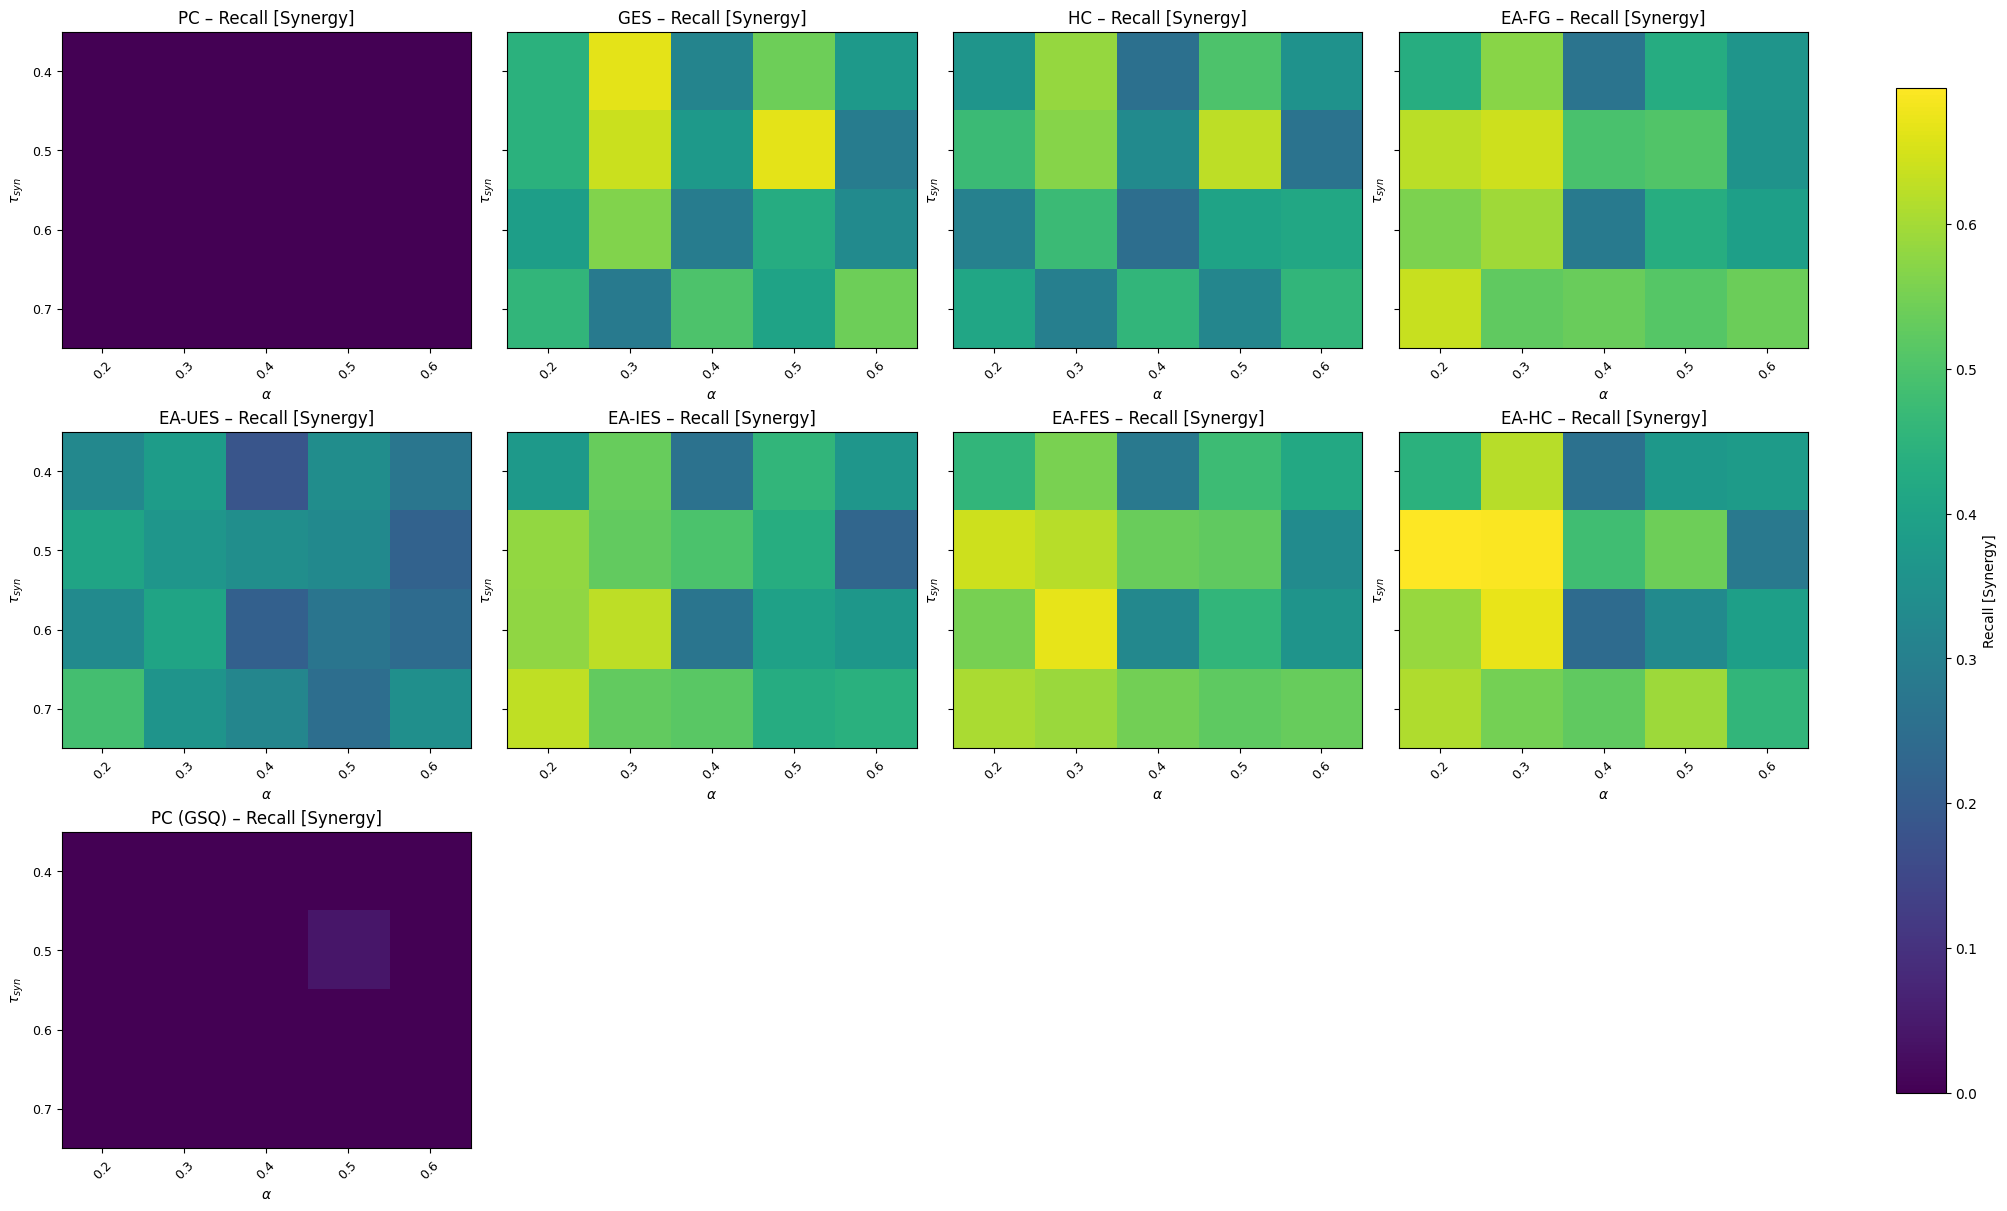

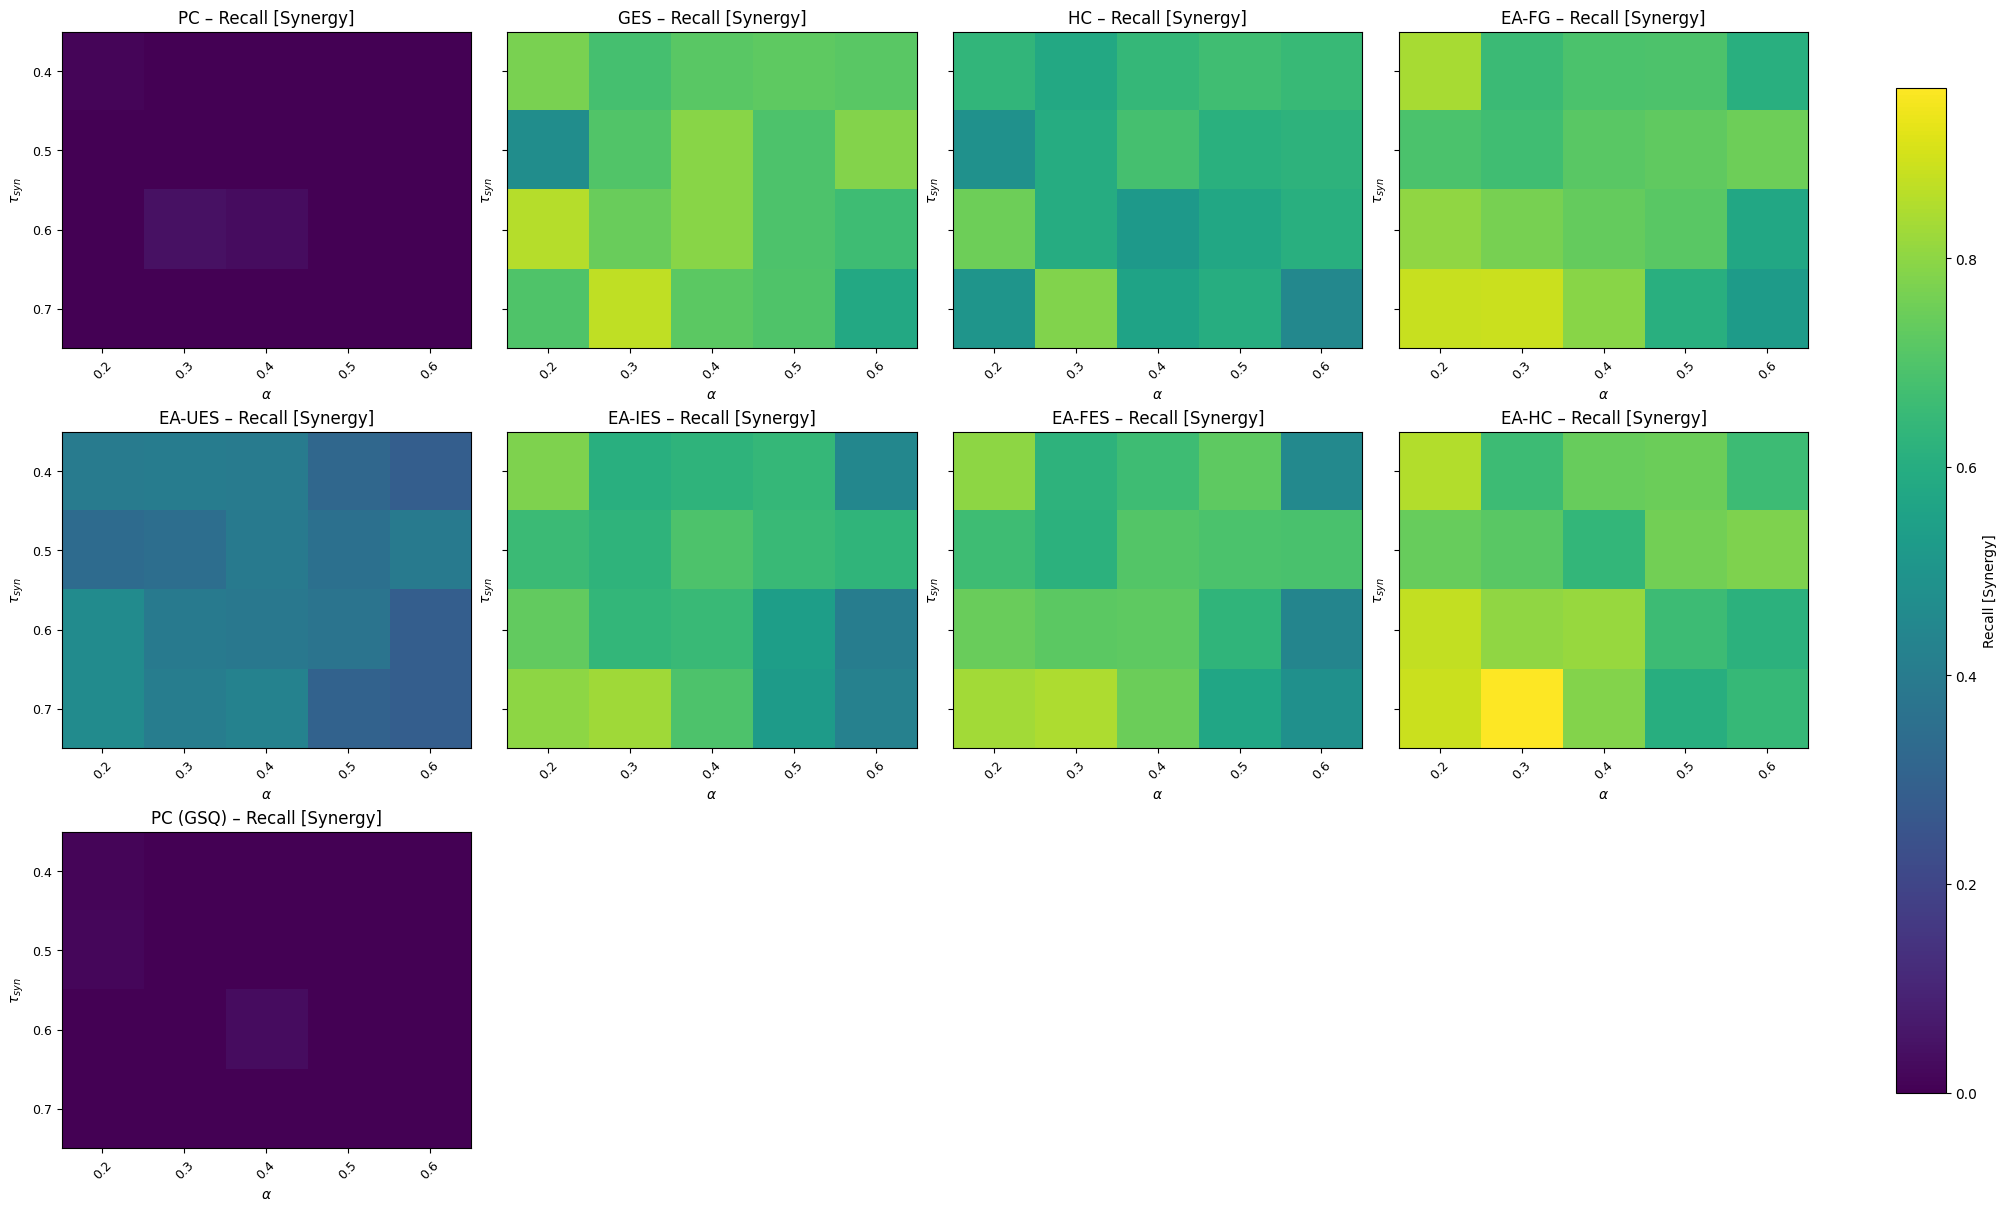

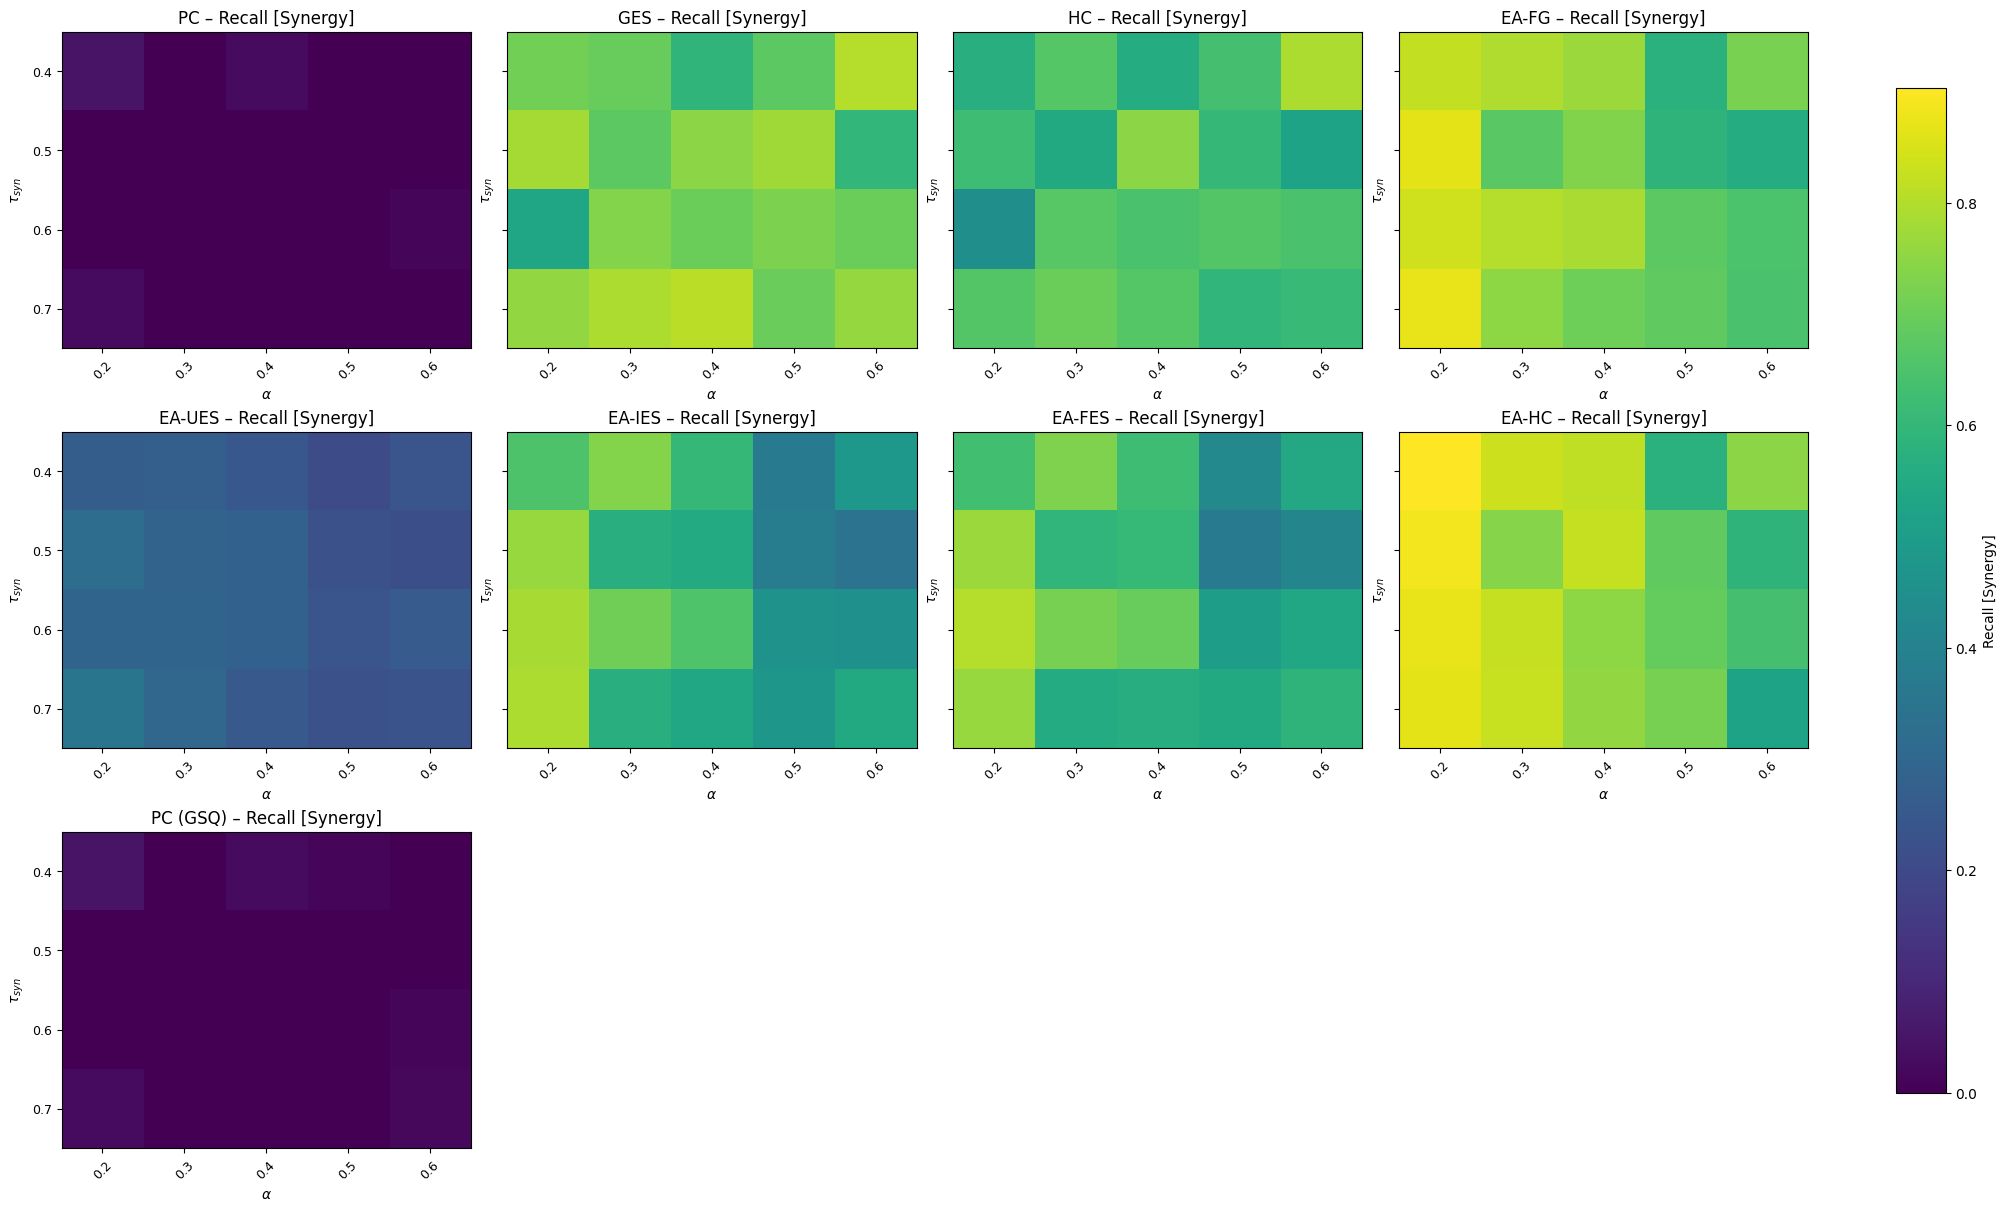

In [30]:
# metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]

metric = "Recall [Synergy]"
x_col = "target_mi"
y_col = "syn_cutoff"

filters = [("num_vars", 10), ("num_vars", 20), ("num_vars", 30)]

# filters = [("pair_probs", )]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        long_df,
        # subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=(filter_col, filter_val),
        y_col=y_col,
    )  
    for ax in axes:
        for a in ax:
            a.set_ylabel(r"$\tau_{syn}$")
            a.set_xlabel(r"$\alpha$")
            labels = [0.20, 0.30, 0.40, 0.50, 0.60]
            a.set_xticks(range(len(labels)))
            a.set_xticklabels(labels)
            
    # plt.savefig(f"plots/{subset}/Fig1_{i}.png", dpi=600, bbox_inches='tight')
    # i += 1
   

## Global (Fig2)

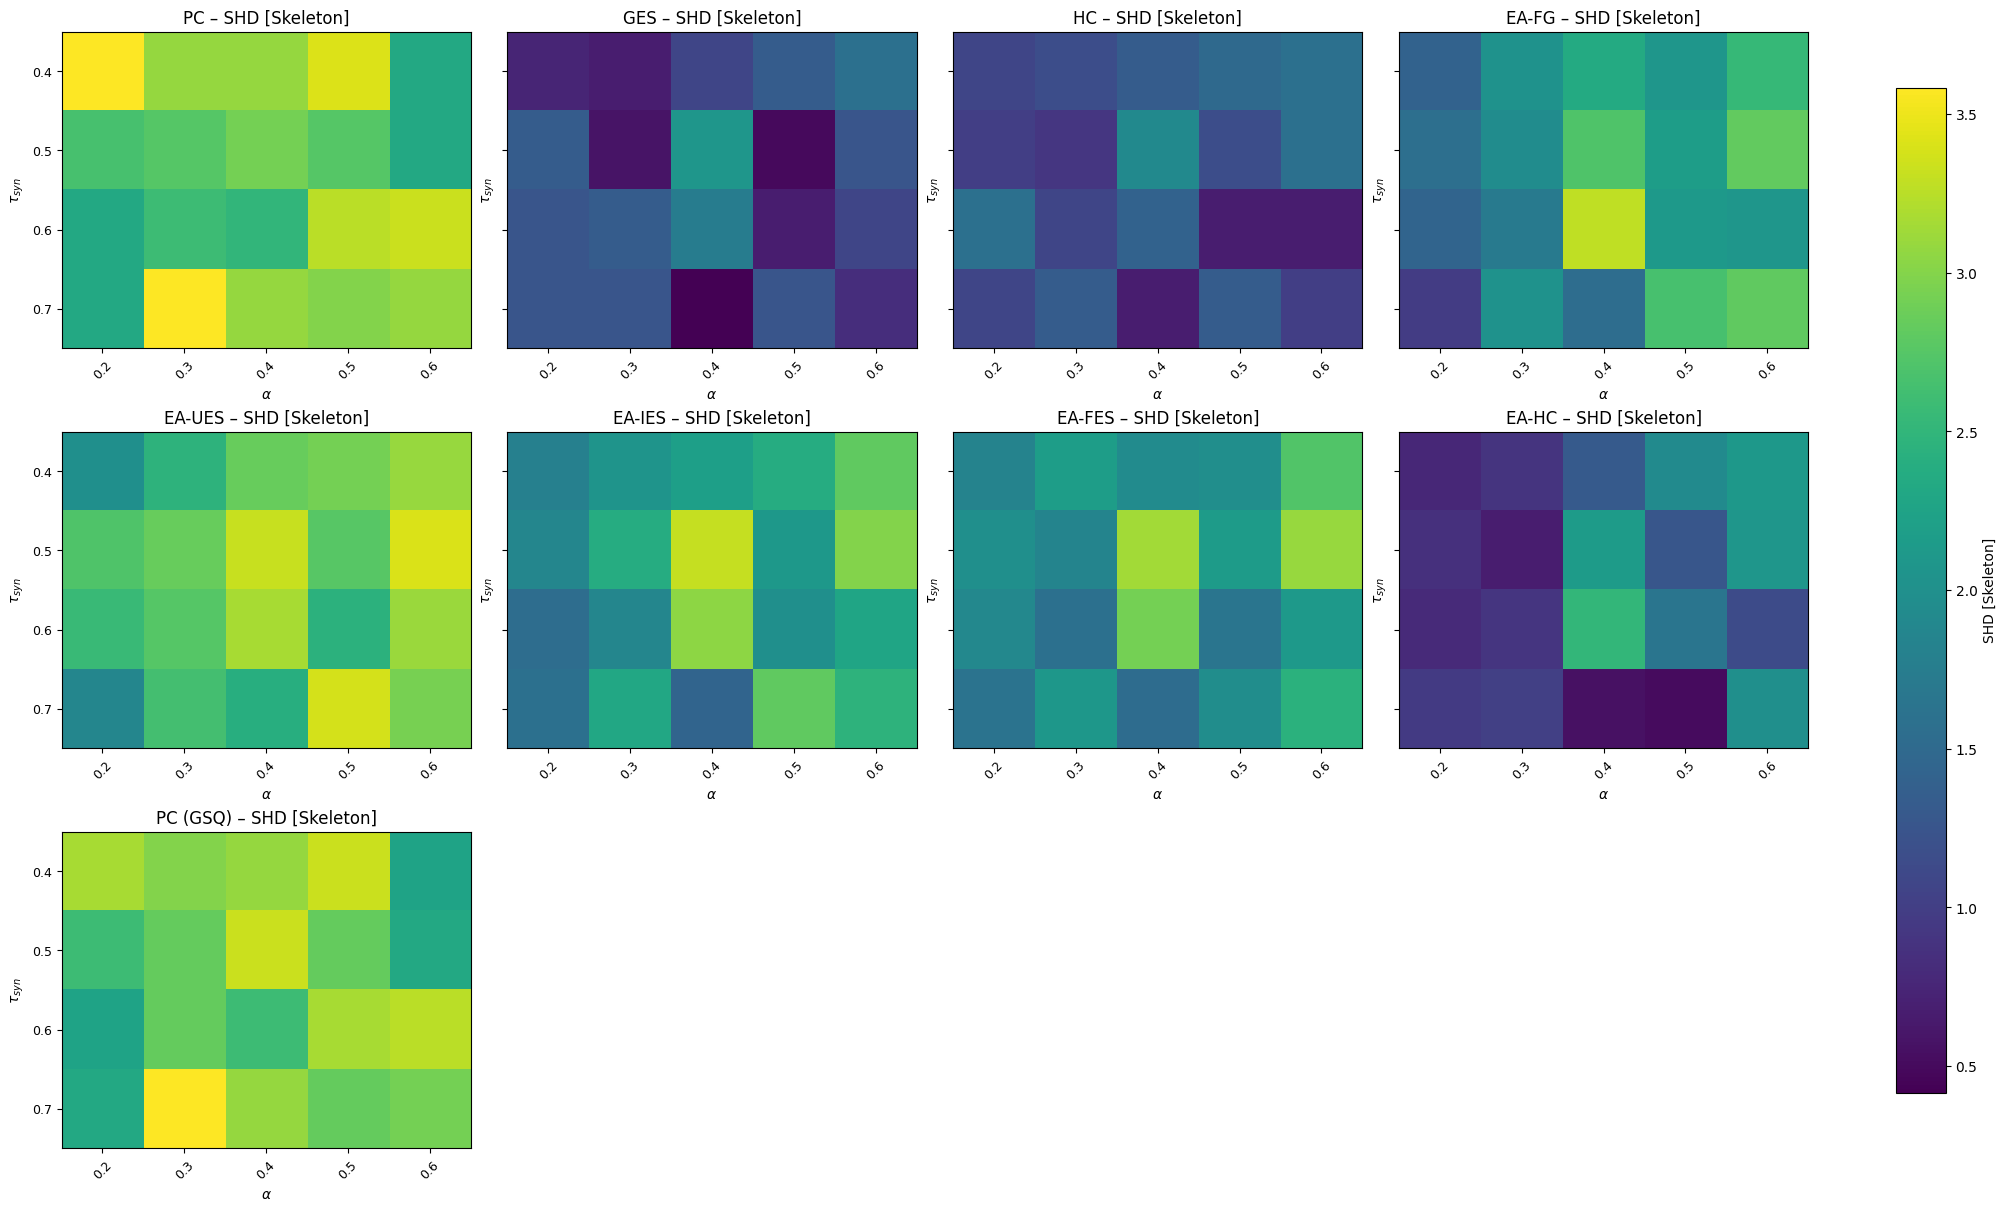

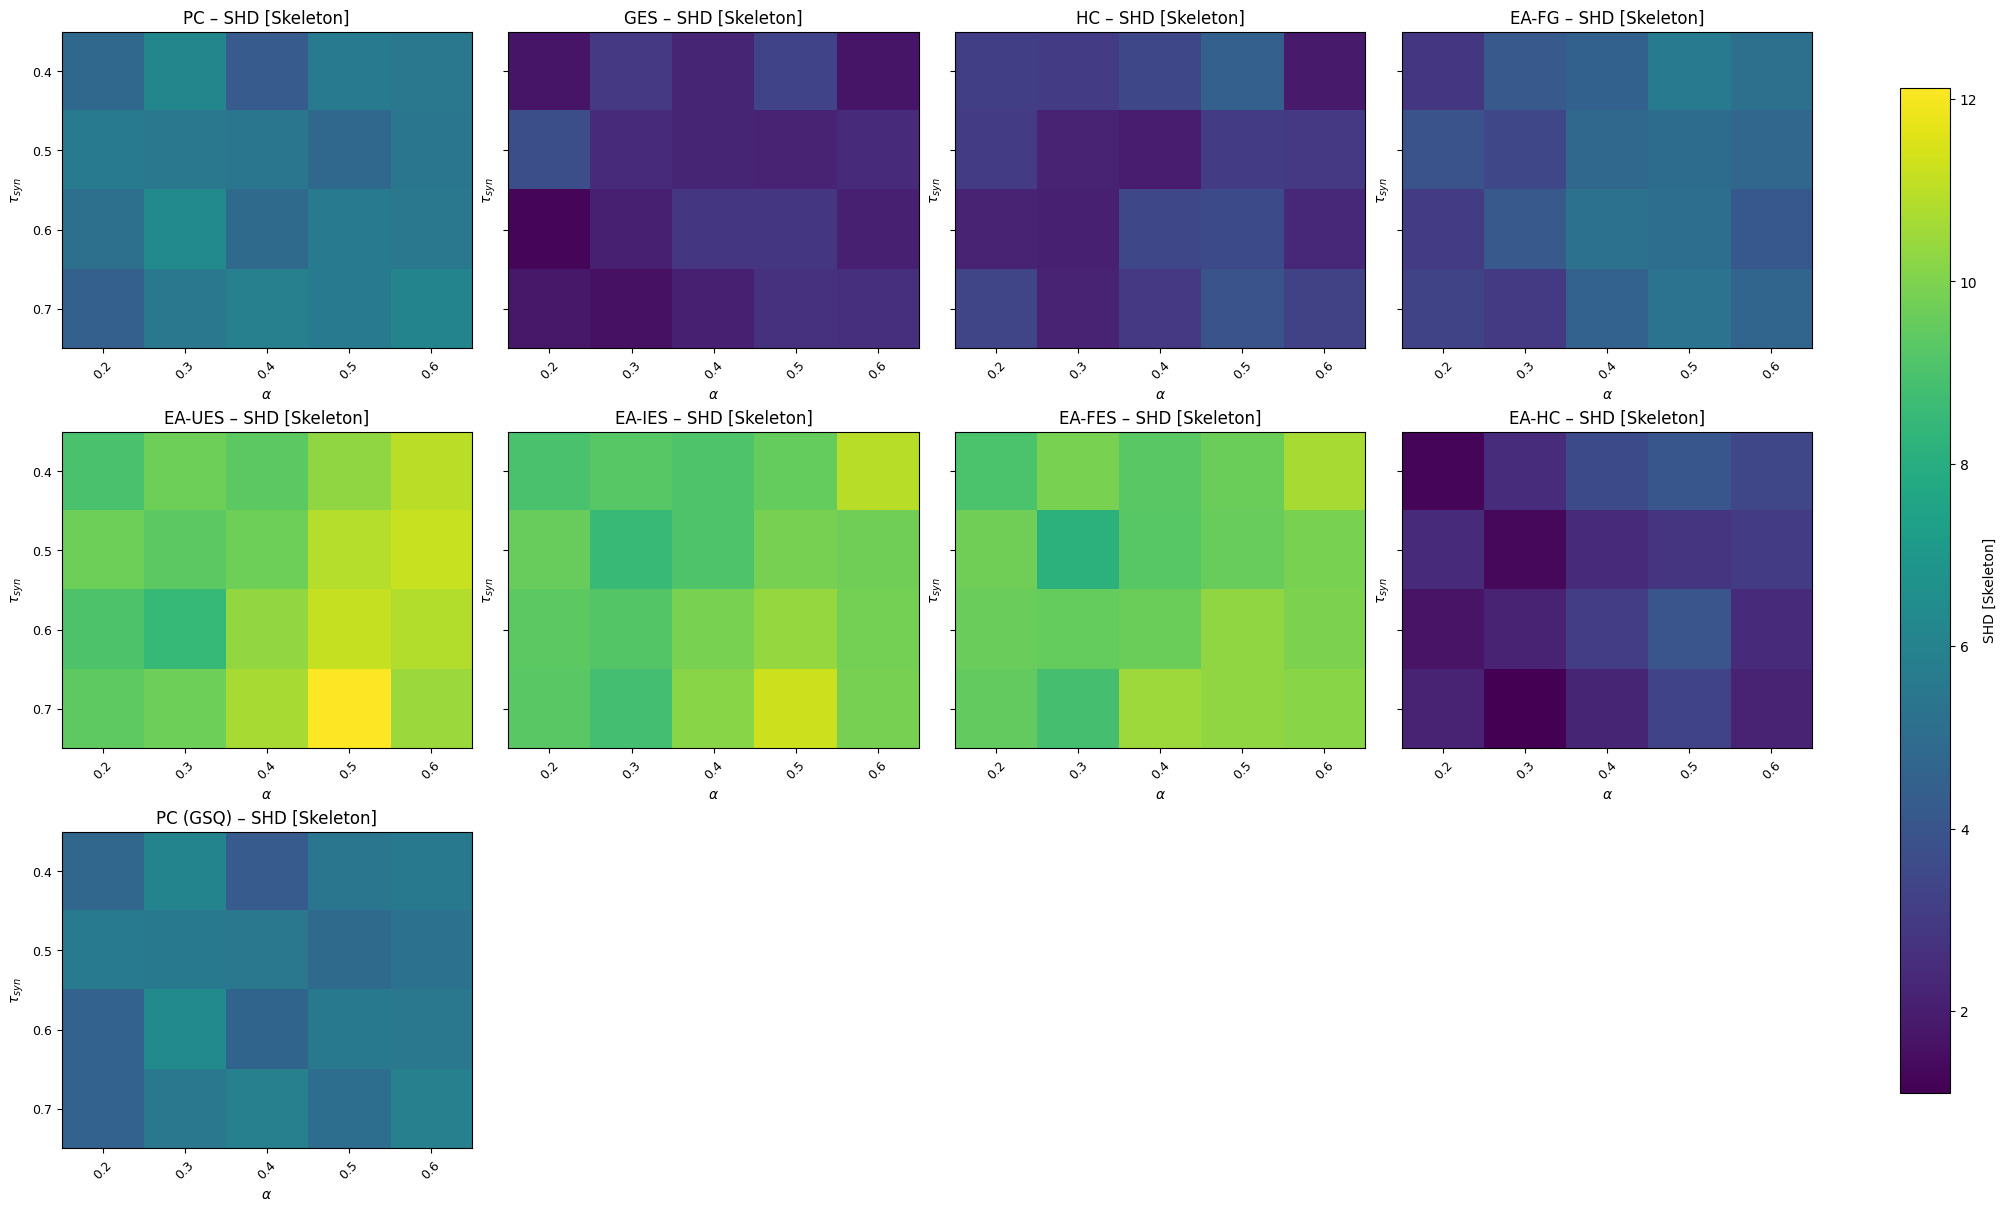

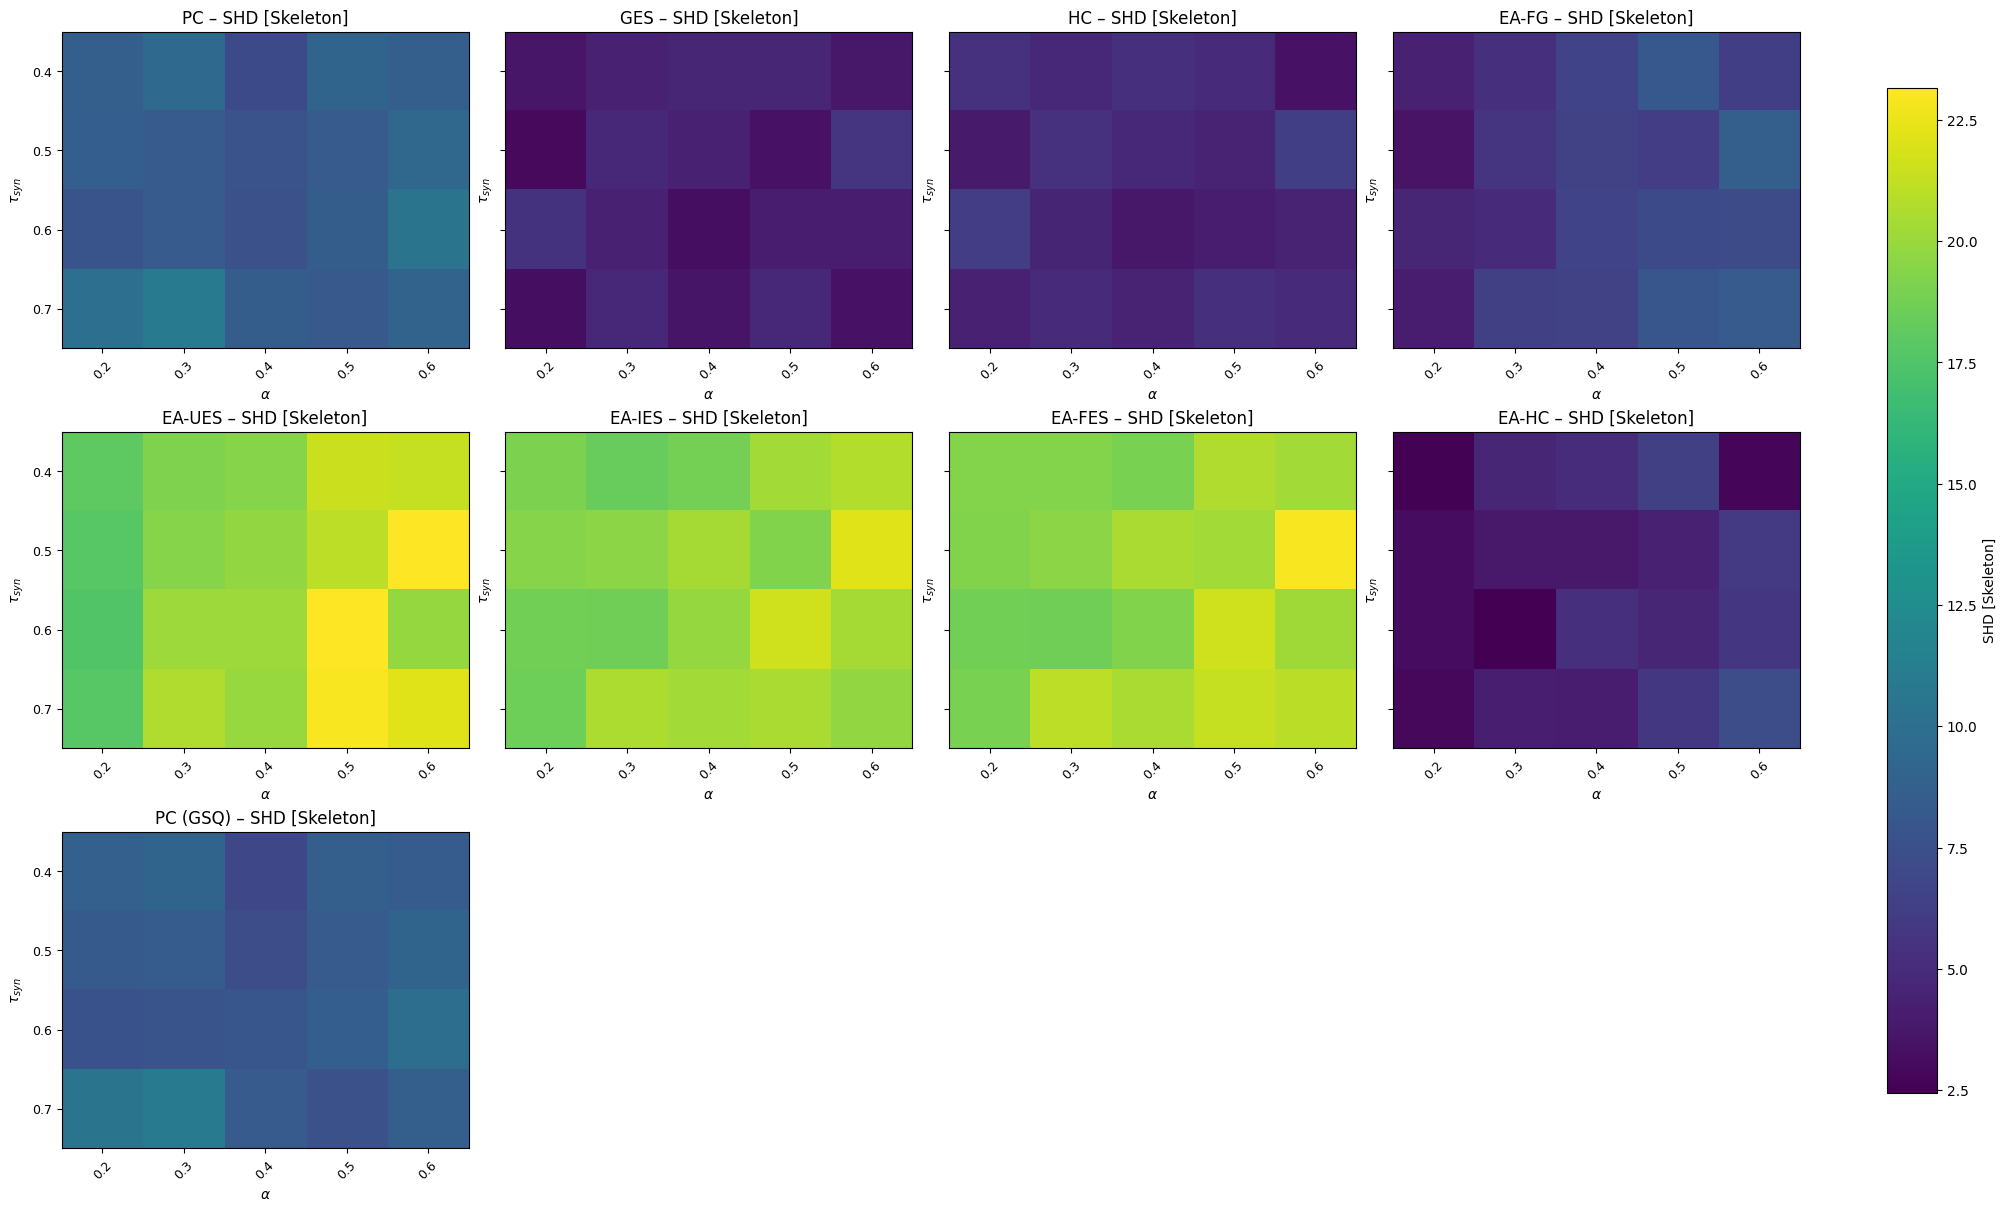

In [31]:

metric = "SHD [Skeleton]"
x_col = "target_mi"
y_col = "syn_cutoff"

filters = [("num_vars", 10), ("num_vars", 20), ("num_vars", 30)]

# filters = [("pair_probs", )]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        long_df,
        # subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=(filter_col, filter_val),
        y_col=y_col,
    )   
    for ax in axes:
        for a in ax:                
            a.set_ylabel(r"$\tau_{syn}$")
            a.set_xlabel(r"$\alpha$")
            labels = [0.20, 0.30, 0.40, 0.50, 0.60]
            a.set_xticks(range(len(labels)))
            a.set_xticklabels(labels)
        # a.set_xticks()
    # plt.savefig(f"plots/{subset}/Fig2_{i}.png", dpi=600, bbox_inches='tight')
    i += 1
   

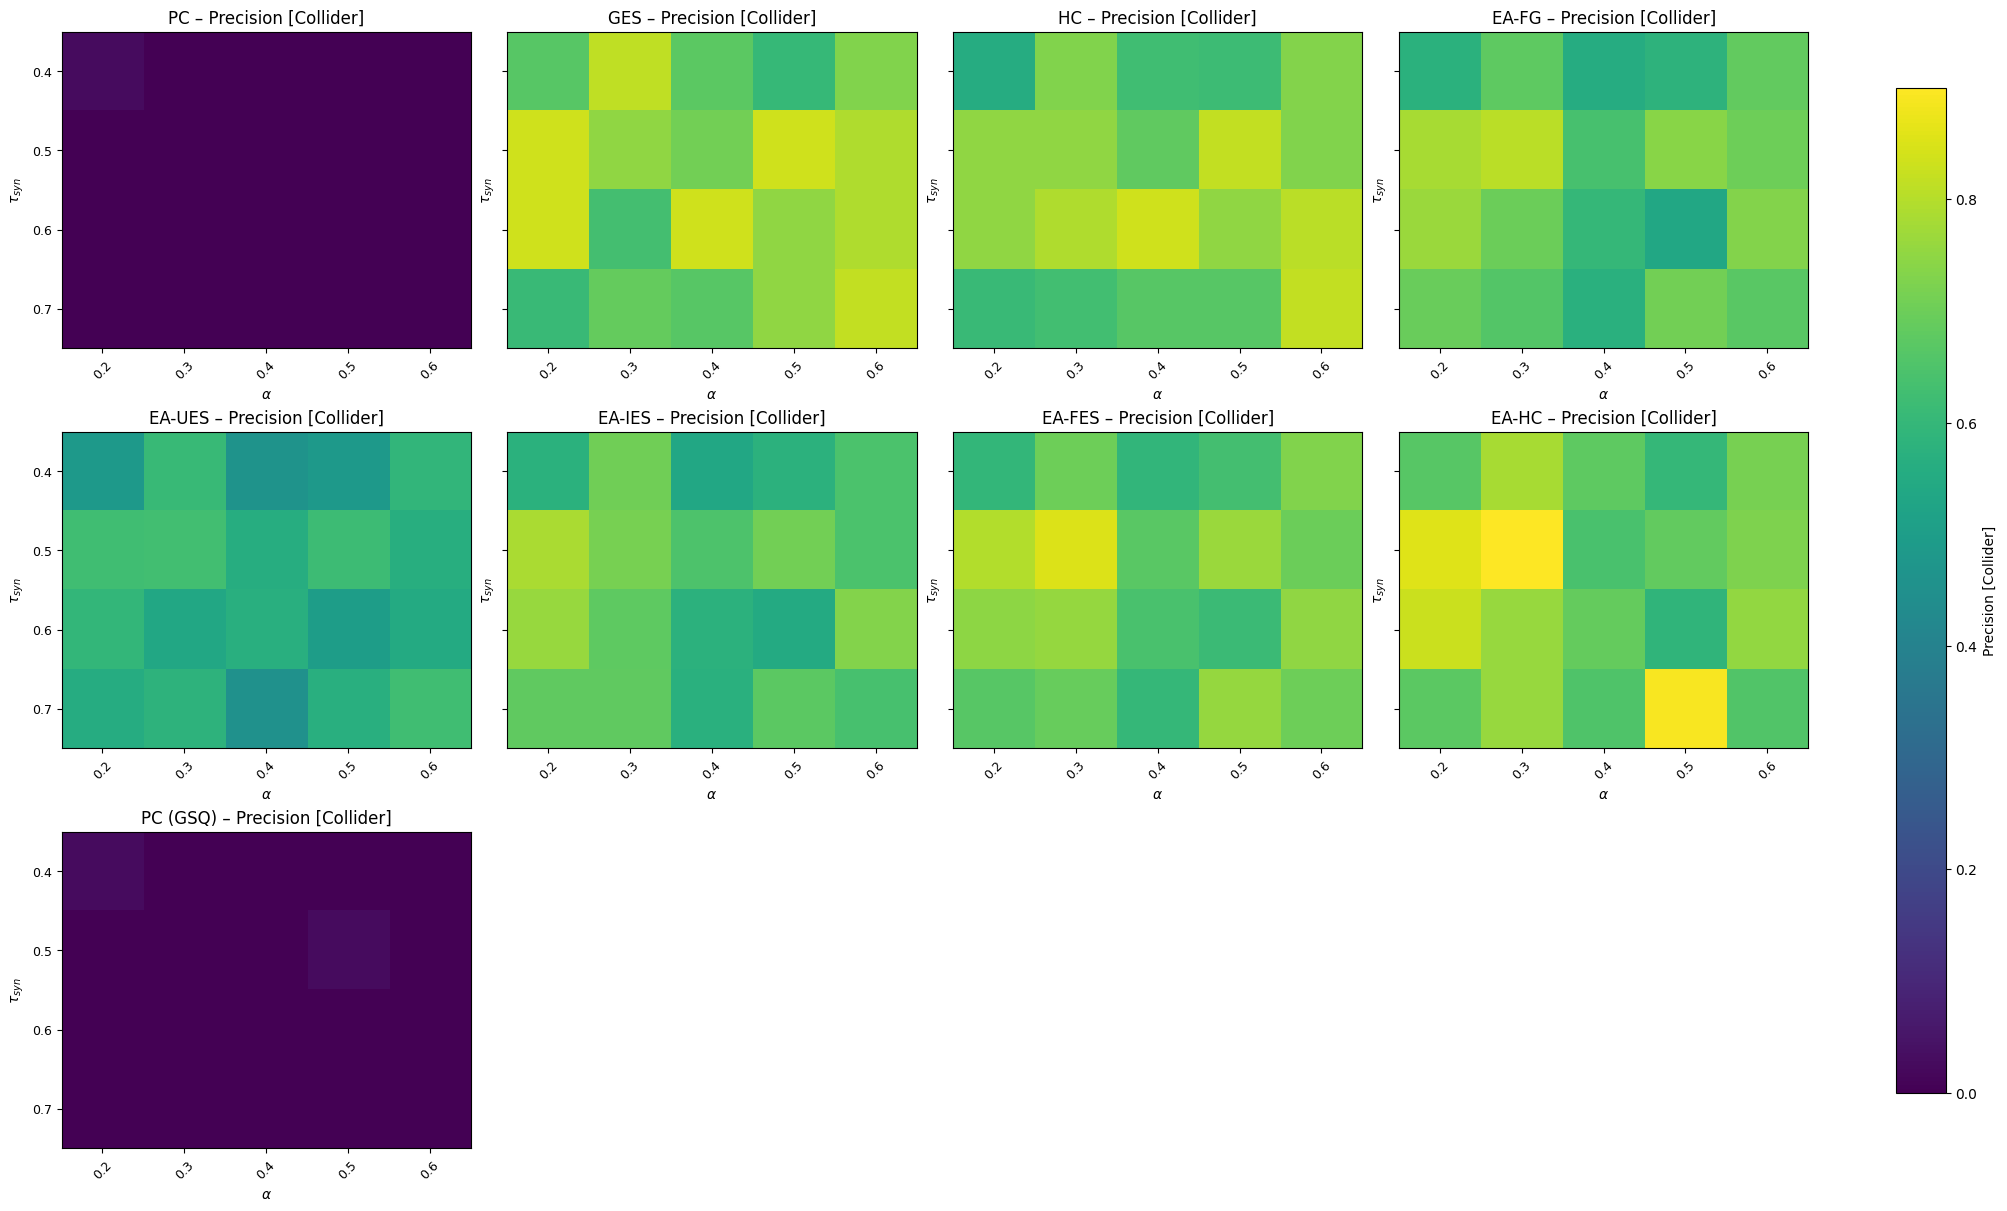

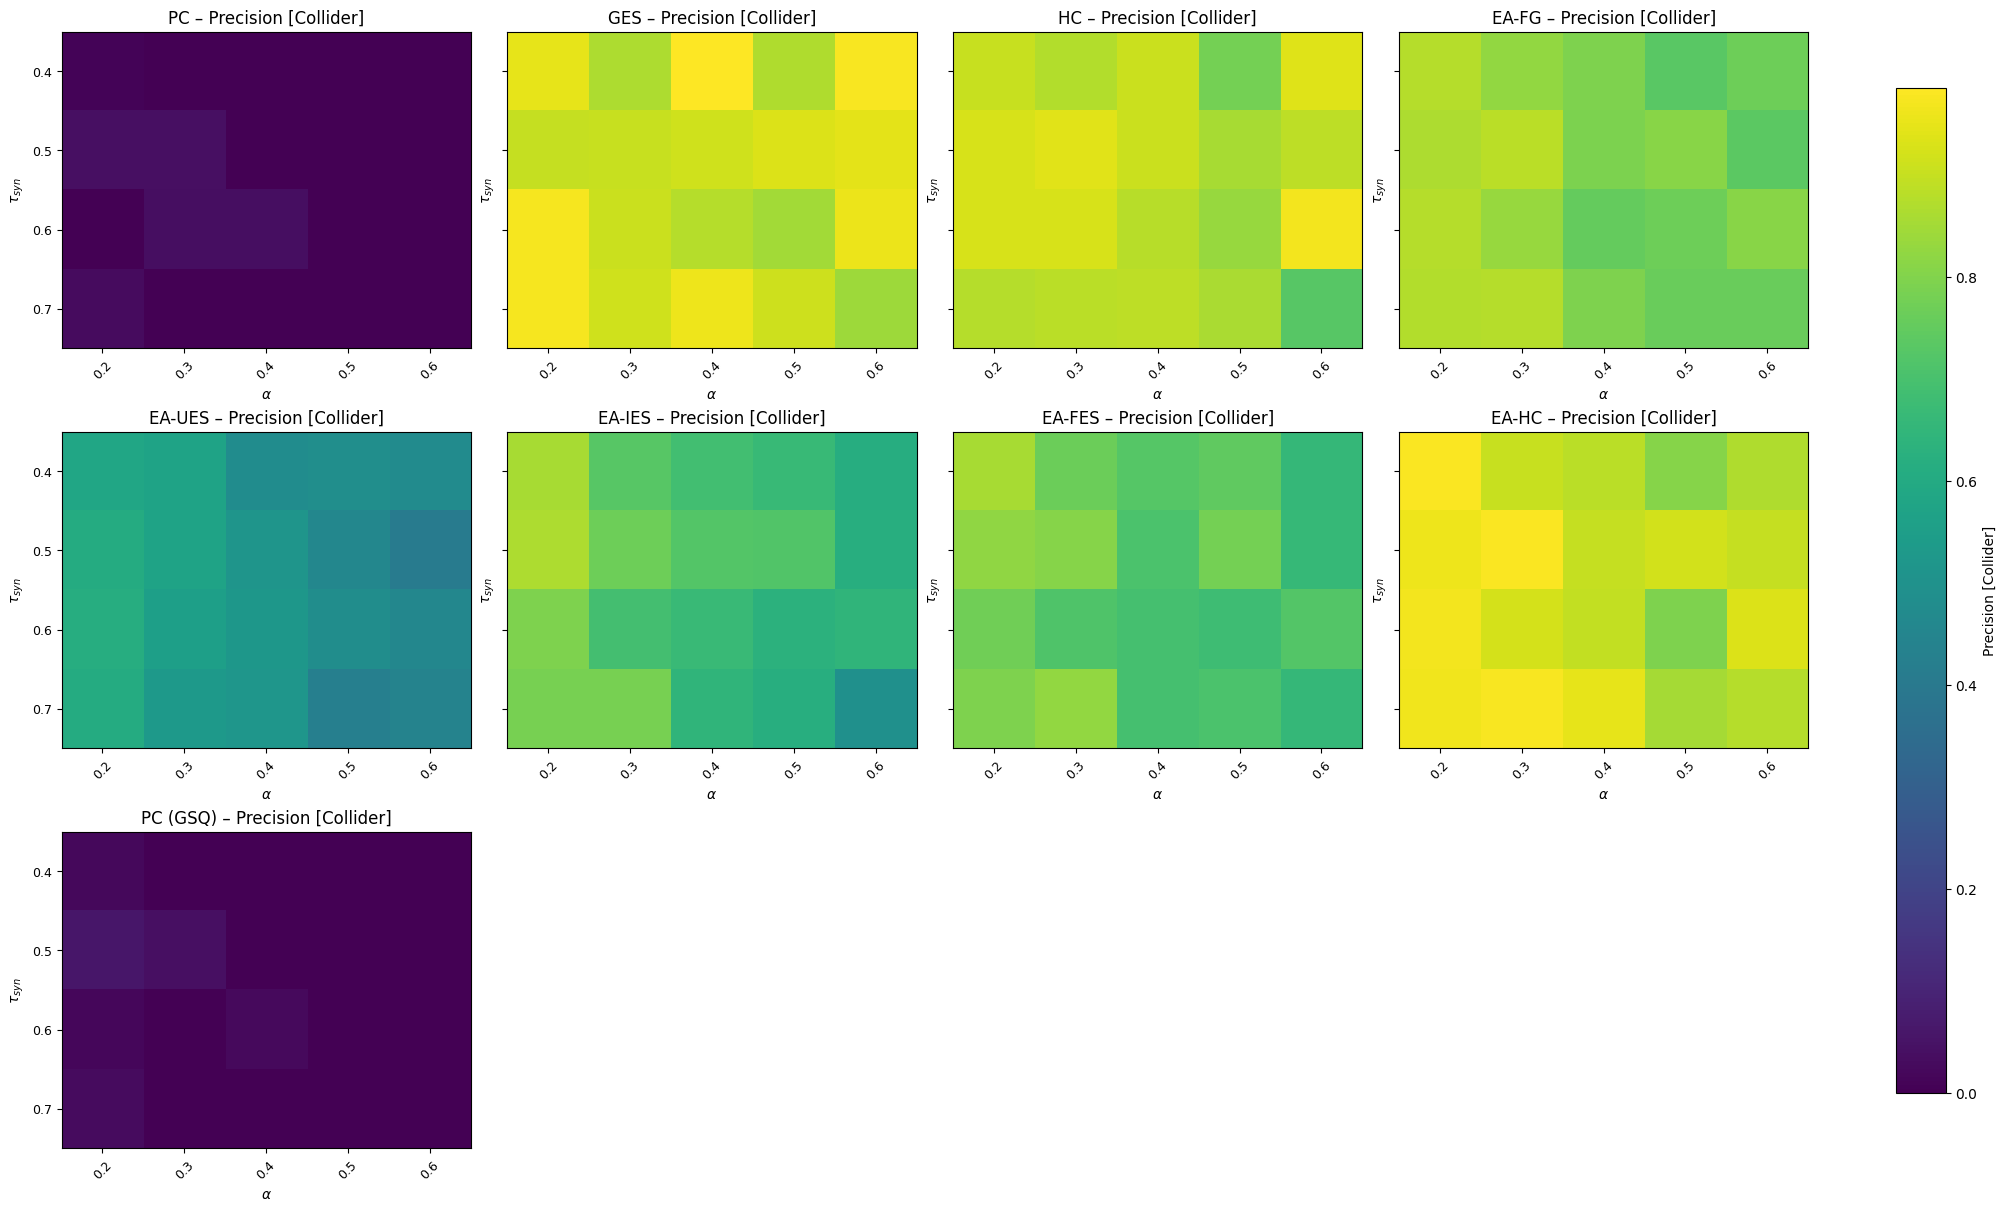

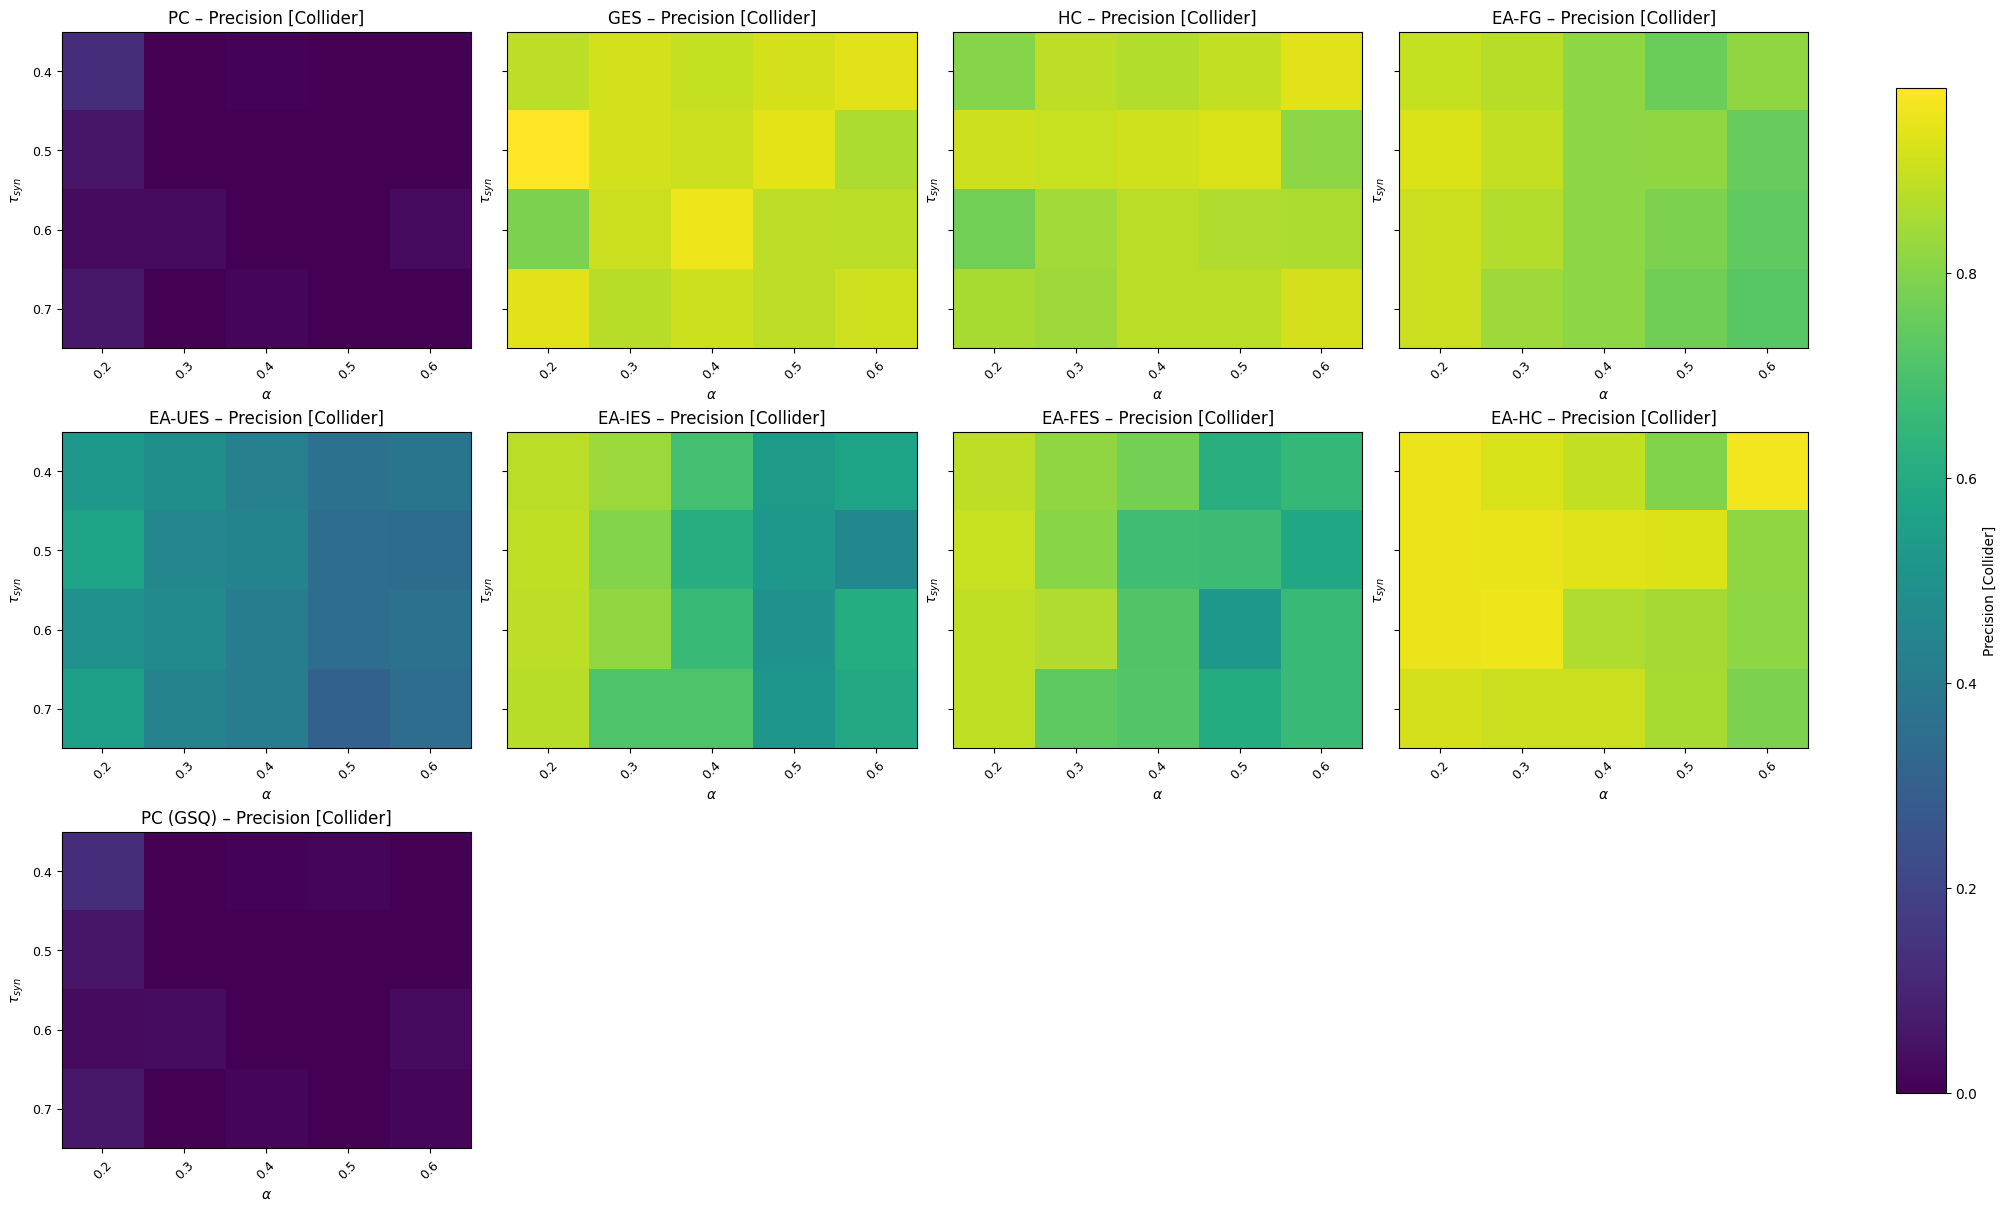

In [32]:

metric = "Precision [Collider]"
x_col = "target_mi"
y_col = "syn_cutoff"

filters = [("num_vars", 10), ("num_vars", 20), ("num_vars", 30)]

# filters = [("pair_probs", )]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        long_df,
        # subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=(filter_col, filter_val),
        y_col=y_col,
    )   
    for ax in axes:
        for a in ax:                
            a.set_ylabel(r"$\tau_{syn}$")
            a.set_xlabel(r"$\alpha$")
            labels = [0.20, 0.30, 0.40, 0.50, 0.60]
            a.set_xticks(range(len(labels)))
            a.set_xticklabels(labels)
        # a.set_xticks()
    plt.savefig(f"plots/{subset}/Fig3_{i}.png", dpi=600, bbox_inches='tight')
    i += 1
   

### Violin Plots

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
subset = "jpmf_data"

def violin_grid_2x3(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


### Metrics

In [46]:
load_results(subset)
long_df = build_long_metrics(results_by_label)
subset_df = long_df[long_df["Total (SC)"] >= 1 & (long_df["Total (PW)"] >= 1)]
target_values = long_df["target_mi"].unique()

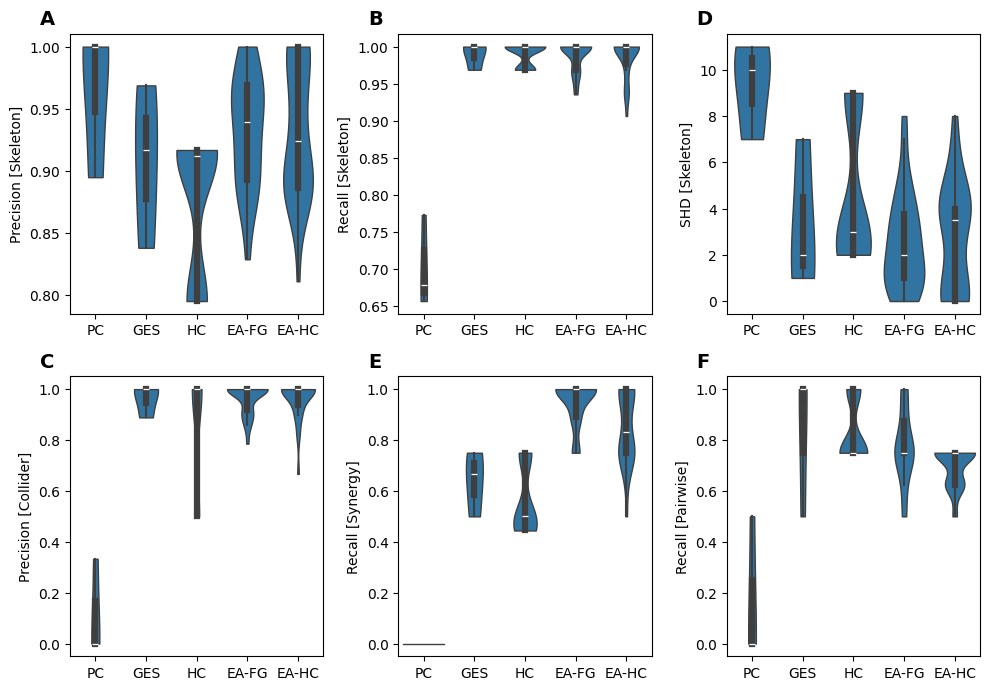

In [48]:
metrics = {
    "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
    "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "C": ("Precision [Collider]", "Precision [Collider]"),
    "E": ("Recall [Synergy]", "Recall [Synergy]"),
    "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
}

alg_order = ["PC", "GES", "HC", "EA-FG", "EA-HC"] 

# Example slice (optional):
filter_dict = {"pair_probs": 0.5, "target_mi": target_values[0], "syn_cutoff": 0.7, "num_vars":30}
# filter_dict = None



fig, axes = violin_grid_2x3(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 7),
)

# plt.savefig(
#     f"plots/{subset}/Fig6.png",
#     dpi=800,
# )


In [ ]:
import pandas as pd



long_df = build_long_metrics(results_by_label)


### Metrics

## 1.3: Tradeoffs EA+HC

In [ ]:
# long_df = build_long_metrics(results_by_label)

# metrics = {
#     "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
#     "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
#     "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
#     "C": ("Precision [Collider]", "Precision [Collider]"),
#     "E": ("Recall [Synergy]", "Recall [Synergy]"),
#     "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
# }

# alg_order = ["PC", "GES", "HC", "EA-FG"]  # or whatever you want


# # Example slice (optional):
# filter_dict = {"pair_probs": 0.5, "syn_cutoff": 0.4, "target_mi": target_values[0]}
# # filter_dict = None

# fig, axes = violin_grid_2x2(
#     long_df,
#     metrics=metrics,
#     alg_order=alg_order,
#     filter_dict=filter_dict,
#     figsize=(10, 7),
# )

# plt.savefig(
#     f"plots/{subset}/Fig7.png",
#     dpi=800,
# )


In [ ]:
# ### Metrics and Algorithms
# np.unique(long_df["Algorithm"])
long_df.columns

Index(['n_nodes', 'n_pairs', 'SHD [Skeleton]', 'Type Confusions [Adjacency]',
       'n_true [Adjacency]', 'n_pred [Adjacency]', 'TP [Adjacency]',
       'FP [Adjacency]', 'FN [Adjacency]', 'Precision [Skeleton]',
       'Recall [Skeleton]', 'F1 [Skeleton]', 'TP (Found Colliders)',
       'FP (Extra Colliders)', 'FN (Missing Colliders )',
       'TP (Synergistic Colliders Found)',
       'FN (Missing Synergistic Colliders)', 'Precision [Collider]',
       'Recall [Collider]', 'F1 [Collider]', 'Precision [Synergy]',
       'Recall [Synergy]', 'F1 [Synergy]', 'TP (Pairwise Colliders Found)',
       'FN (Missing Pairwise Colliders)', 'Precision [Pairwise]',
       'Recall [Pairwise]', 'F1 [Pairwise]', 'i', 'family', 'target_mi',
       'pair_probs', 'syn_cutoff', 'num_vars', 'TrueBIC', 'BIC', 'WallTime_s',
       'CPUTime_s', 'RSS_before_MB', 'RSS_after_MB', 'RSS_delta_MB',
       'PeakRSS_MB', 'PyAllocPeak_MB', 'Algorithm', 'run_id'],
      dtype='object')

In [ ]:
import pandas as pd

def _eval_to_df(eval_metrics):
    if eval_metrics is None:
        return None
    if isinstance(eval_metrics, pd.DataFrame):
        return eval_metrics.copy()
    if isinstance(eval_metrics, pd.Series):
        return eval_metrics.to_frame().T
    if isinstance(eval_metrics, dict):
        return pd.DataFrame([eval_metrics])
    return None

def build_long_metrics(results_by_label):
    rows = []
    for alg, results_list in results_by_label.items():
        for i, res in enumerate(results_list):
            em = getattr(res, "eval_metrics", None)
            df_em = _eval_to_df(em)
            if df_em is None or len(df_em) == 0:
                continue
            df_em = df_em.copy()
            df_em["Algorithm"] = alg
            df_em["run_id"] = i
            rows.append(df_em)
    return pd.concat(rows, ignore_index=True)

# load_results("jpmf_data")
# long_df = build_long_metrics(results_by_label)
# long_df = long_df[long_df["Total (SC)"] >= 1]


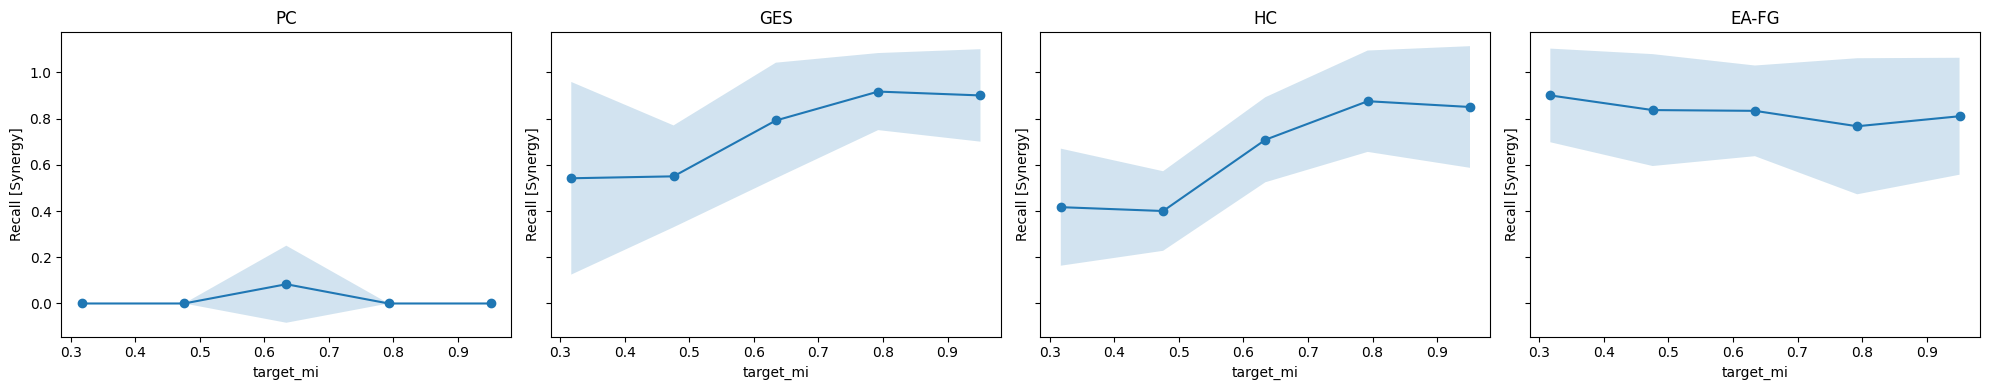

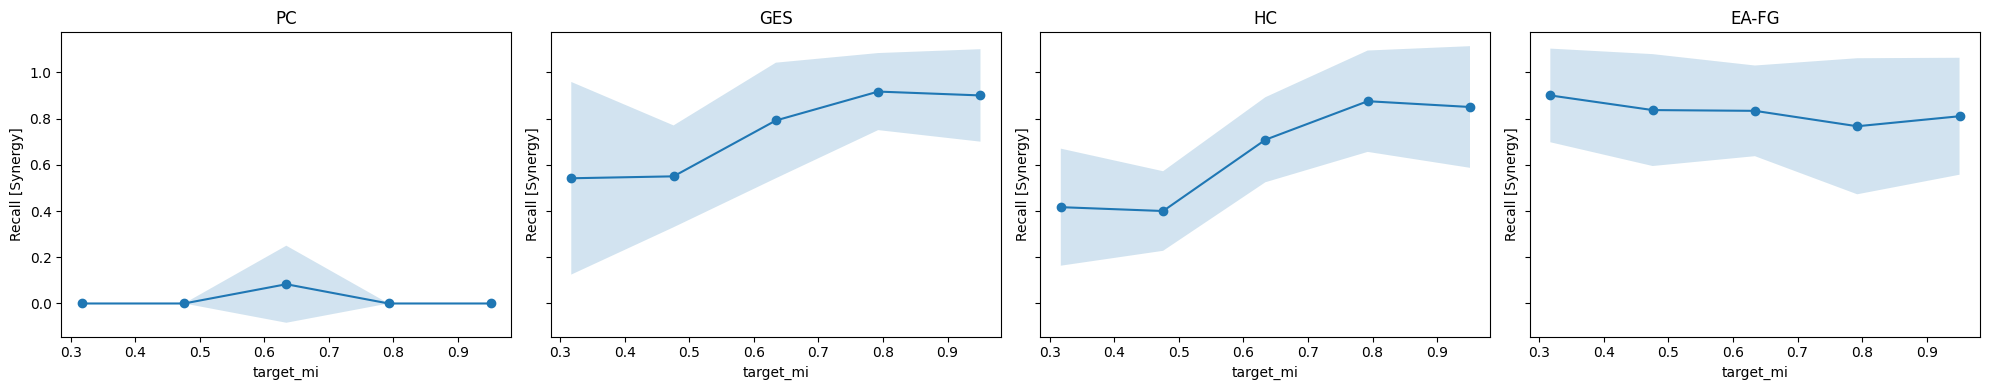

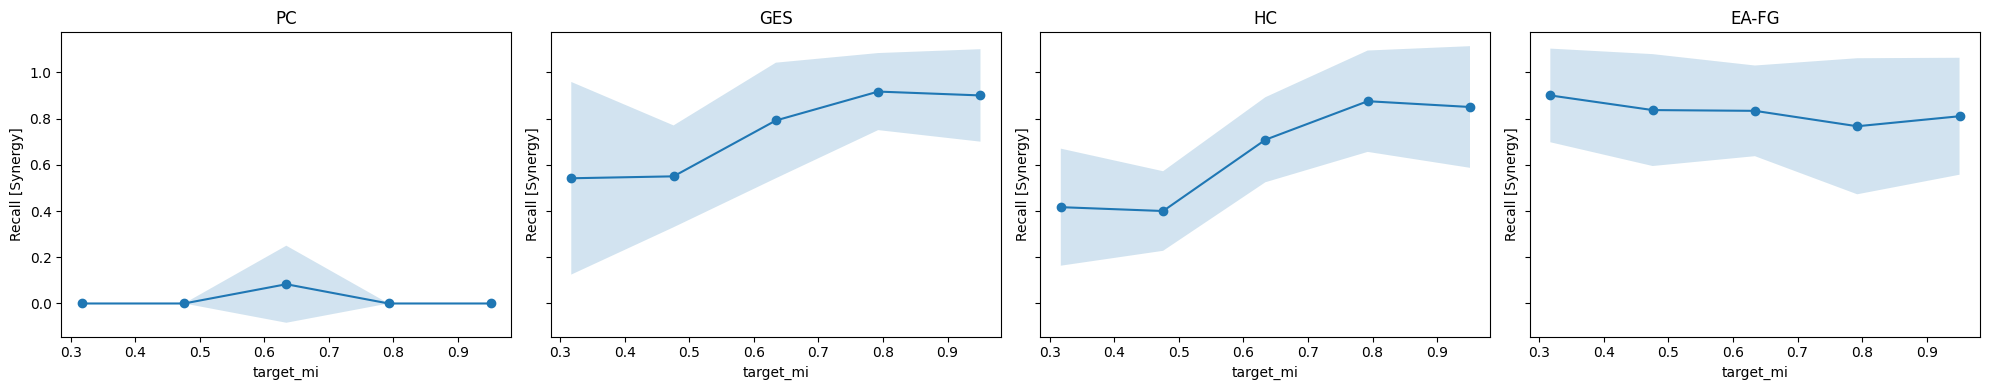

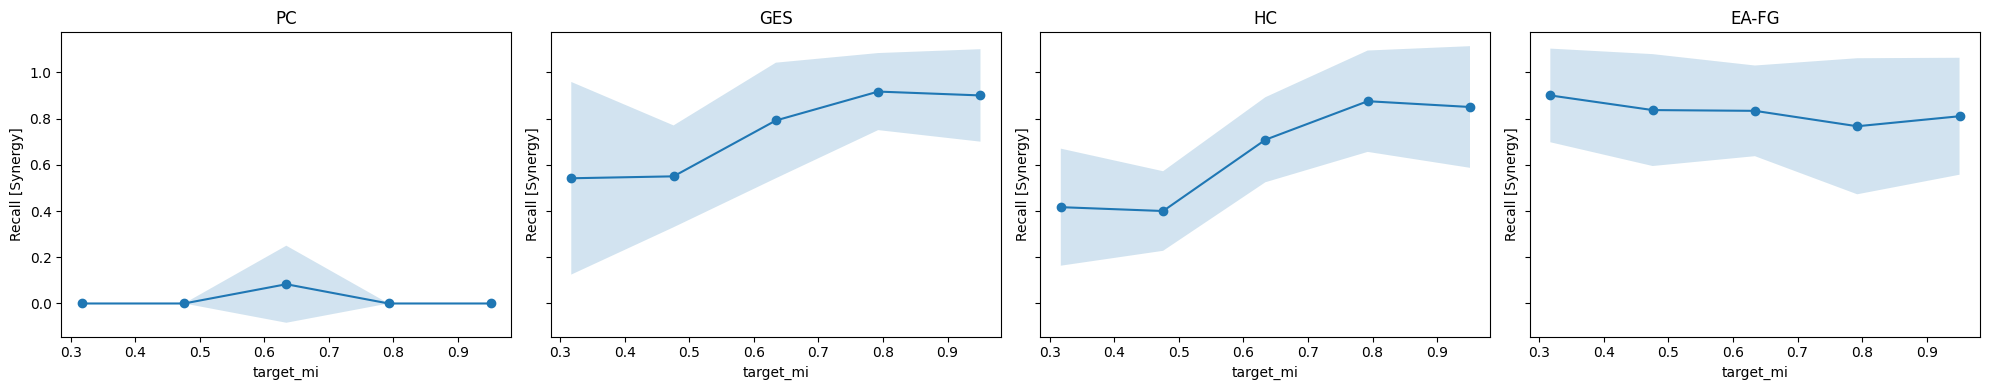

In [ ]:
# load_results("jpmf_data")
# long_df = build_long_metrics(results_by_label)
long_df = long_df[long_df["Total (SC)"] >= 1 & (long_df["Total (PW)"] >= 1)]
# six_sc = long_df[long_df["Total (SC)"] == 6]

x_col = "target_mi"
by = "syn_cutoff"
y_col = "Recall [Synergy]"

# df_subset = long_df[
#     (long_df['TP (Synergistic Colliders Found)'] > 0) &
#     (long_df['FN (Missing Synergistic Colliders)'] > 0)
# ]

filter_dict = {"num_vars":30, "pair_probs": 0.7, "family":"ba"}


for k, v in filter_dict.items():
    long_df = long_df[long_df[k] == v]

for i in long_df["syn_cutoff"].unique():
    fig, ax = plot_final_metric_vs_x(
    long_df,
    metric_col=y_col,
    x_col="target_mi",
    by=None,
    band="std",
    ylabel=y_col,
    ncols=4,
    shared_legend=True,
    legend_loc="upper center",
)

In [ ]:
# for algo in long_df["Algorithm"].unique():
#     subset_algo = long_df[long_df["Algorithm"] == algo]
#     print(f"Algorithm: {algo}")

#     plot_metric_vs_x(
#         subset_algo,
#         metric_col="Recall [Synergy]",
#         x_col="target_mi",
#         by="syn_cutoff",
#         band="std",
#         ylabel="Recall [Synergy]",
#     )